In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"D:\New folder\Govt_Scheme_Dataset_10L_15_Schemes.csv")

In [3]:
df.head()

,CitizenID,Name,PhoneNumber,Age,Gender,Income,Farmer,Student,Disability,BPL,Occupation,District,MaritalStatus,GirlChild,StreetVendor,Artisan,WomanSHG,RuralHousehold,Scheme
0,CIT0000001,Pooja,7463865876,71,Male,568454.0,Yes,No,Yes,No,Labour,Dimapur,Single,No,No,No,No,Yes,Atal Pension Yojana
1,CIT0000002,Arjun,7166266865,22,Female,31285.0,No,No,Yes,Yes,Vendor,Kohima,Married,No,Yes,No,No,No,PM Ujjwala Yojana
2,CIT0000003,Anita,9714752920,62,Female,475476.0,No,No,No,No,Teacher,Kohima,Married,No,No,No,No,Yes,National Social Assistance Programme (NSAP)
3,CIT0000004,Arjun,7499618542,52,Female,385153.0,No,No,No,No,Labour,Dimapur,Single,No,No,No,No,No,Atal Pension Yojana
4,CIT0000005,Rohit,7210682619,78,Female,220773.0,No,No,No,No,Business,Mon,Married,No,No,No,No,No,PM Mudra Yojana


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   CitizenID       1000000 non-null  str    
 1   Name            1000000 non-null  str    
 2   PhoneNumber     1000000 non-null  int64  
 3   Age             1000000 non-null  int64  
 4   Gender          1000000 non-null  str    
 5   Income          980092 non-null   float64
 6   Farmer          1000000 non-null  str    
 7   Student         1000000 non-null  str    
 8   Disability      1000000 non-null  str    
 9   BPL             1000000 non-null  str    
 10  Occupation      1000000 non-null  str    
 11  District        1000000 non-null  str    
 12  MaritalStatus   1000000 non-null  str    
 13  GirlChild       1000000 non-null  str    
 14  StreetVendor    1000000 non-null  str    
 15  Artisan         1000000 non-null  str    
 16  WomanSHG        1000000 non-null  str    
 17  R

In [5]:
df.describe()

,PhoneNumber,Age,Income
count,1.000000e+06,1000000.000000,980092.000000
mean,7.974961e+09,42.291426,347938.515822
std,1.233247e+09,22.139095,203177.465283
min,1.234500e+04,-5.000000,-1000.000000
25%,6.989737e+09,23.000000,171816.000000
50%,7.991614e+09,42.000000,347938.000000
75%,8.996137e+09,61.000000,523777.250000
max,9.999999e+09,80.000000,700000.000000


In [6]:
df.shape

(1000000, 19)

In [7]:
df.columns

Index(['CitizenID', 'Name', 'PhoneNumber', 'Age', 'Gender', 'Income', 'Farmer',
       'Student', 'Disability', 'BPL', 'Occupation', 'District',
       'MaritalStatus', 'GirlChild', 'StreetVendor', 'Artisan', 'WomanSHG',
       'RuralHousehold', 'Scheme'],
      dtype='str')

In [8]:
df.isnull().sum()

CitizenID             0
Name                  0
PhoneNumber           0
Age                   0
Gender                0
Income            19908
Farmer                0
Student               0
Disability            0
BPL                   0
Occupation            0
District              0
MaritalStatus         0
GirlChild             0
StreetVendor          0
Artisan               0
WomanSHG              0
RuralHousehold        0
Scheme                0
dtype: int64

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

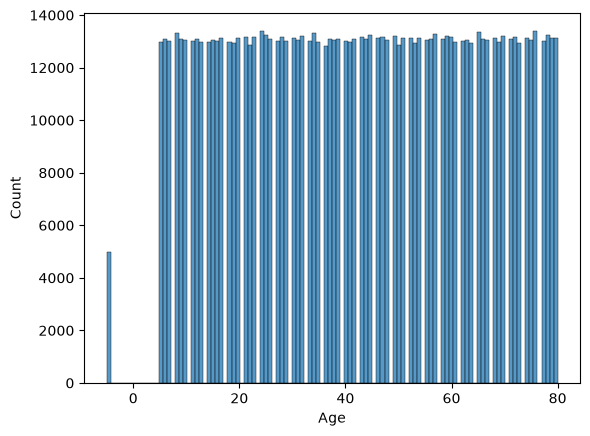

In [10]:
sns.histplot(df["Age"])
plt.show()

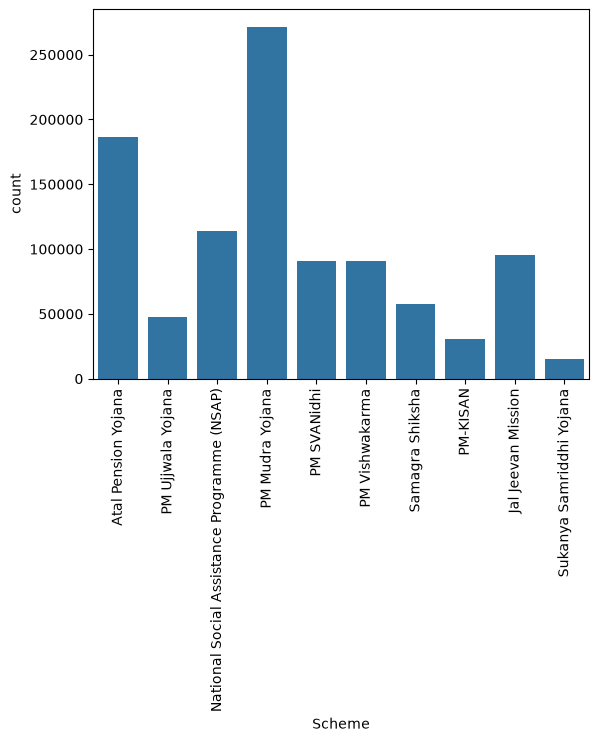

In [11]:
sns.countplot(x="Scheme", data=df)
plt.xticks(rotation=90)
plt.show()

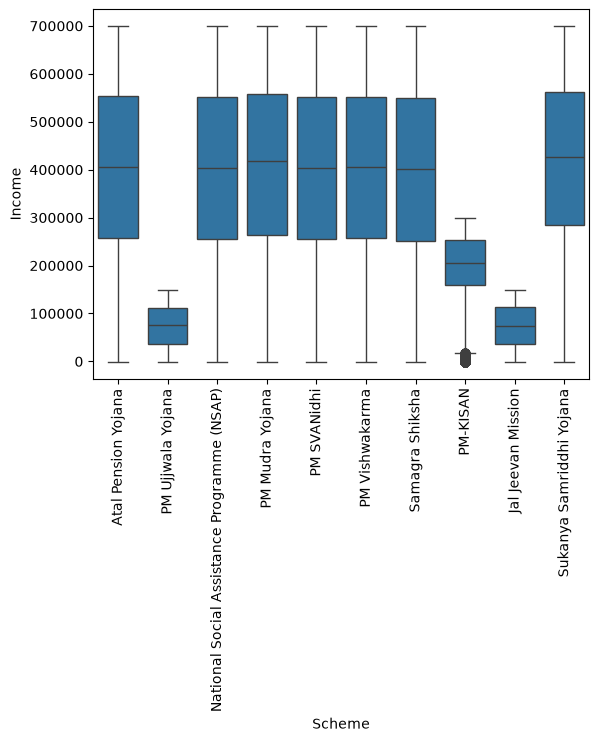

In [12]:
sns.boxplot(x="Scheme", y="Income", data=df)
plt.xticks(rotation=90)
plt.show()

In [13]:
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
df["Income"] = df["Income"].fillna(df["Income"].mean())

In [14]:
df = df.drop_duplicates()

In [15]:
df = df[(df["Age"] >= 0) & (df["Age"] <= 100)]

In [16]:
df.isnull().sum()

CitizenID         0
Name              0
PhoneNumber       0
Age               0
Gender            0
Income            0
Farmer            0
Student           0
Disability        0
BPL               0
Occupation        0
District          0
MaritalStatus     0
GirlChild         0
StreetVendor      0
Artisan           0
WomanSHG          0
RuralHousehold    0
Scheme            0
dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le = LabelEncoder()

In [19]:
columns = [
    "Gender",
    "Farmer",
    "Student",
    "Disability",
    "BPL",
    "Occupation",
    "District",
    "MaritalStatus",
    "GirlChild",
    "StreetVendor",
    "Artisan",
    "WomanSHG",
    "RuralHousehold",
    "Scheme"
]

for col in columns:
    df[col] = le.fit_transform(df[col])

In [20]:
X = df[
[
"Age",
"Gender",
"Income",
"Farmer",
"Student",
"Disability",
"BPL",
"Occupation",
"District",
"MaritalStatus",
"GirlChild",
"StreetVendor",
"Artisan",
"WomanSHG",
"RuralHousehold"
]]

In [21]:
y = df["Scheme"]

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [26]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [27]:
prediction = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy =", accuracy)

Accuracy = 0.9991022018879122


In [30]:
importance = model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, score)

Age 0.09866683488677849
Gender 0.02920417240242357
Income 0.08039198970250834
Farmer 0.013841864415287248
Student 0.032741212363497536
Disability 0.012527509258925516
BPL 0.0591018967989623
Occupation 0.4430522737229687
District 0.0031579732216328632
MaritalStatus 0.0006858772245831848
GirlChild 0.01980748003616942
StreetVendor 0.06292307405739744
Artisan 0.07223233894154805
WomanSHG 0.001070601743032176
RuralHousehold 0.07059490122428536


In [31]:
new_data = [[
45,
0,
120000,
1,
0,
0,
1,
2,
3,
1,
0,
0,
0,
0,
1
]]

In [32]:
result = model.predict(new_data)

print(result)

[1]


C:\Users\emanu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
result = model.predict(new_data)

print(result)

[1]


C:\Users\emanu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
